# VRP PoC: RouteFinder with Goods-Type Constraints

This notebook demonstrates optimizing logistics routes using the RouteFinder model with a **pre-computation filter** for goods-type constraints (Frozen vs Dry).

### Problem Constraints

**Active constraints:**
- **Capacity (C)**: Total load (LDM) per route cannot exceed truck capacity.
- **Open route (O)**: Trucks do not return to the depot after the last customer.
- **Goods type (pre-filter)**: Each truck can only carry certain goods (A=Frozen, B=Dry). Orders are filtered before the model sees them.

**Present in data but not enforced:**
- **Time windows**: Orders have `time_window` (e.g. 0–2 days), but the prepare function sets `time_windows` to `[0, inf]` for all nodes.
- **Distance limit**: Set to infinity.
- **Backhaul**: Not used (`demand_backhaul` is 0).

**Summary:** Using **OVRP** (Open VRP with capacity) plus a **goods-type pre-filter**.

## Setup & Data Loading

In [5]:
import json
import os
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
from tensordict import TensorDict

import torchrl.data.tensor_specs as _tensor_specs
from torchrl.data import Bounded, Composite, UnboundedContinuous, UnboundedDiscrete
for name, cls in [("CompositeSpec", Composite), ("BoundedTensorSpec", Bounded),
                  ("UnboundedContinuousTensorSpec", UnboundedContinuous), ("UnboundedDiscreteTensorSpec", UnboundedDiscrete)]:
    if not hasattr(_tensor_specs, name):
        setattr(_tensor_specs, name, cls)

warnings.filterwarnings("ignore", message=".*weights_only.*", category=FutureWarning)
from routefinder.envs import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase

DATA_PATH = next((p for p in ["logistics_data.json", "demos/logistics_data.json"] if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Run 'python demos/generate_data.py' from project root first.")
with open(DATA_PATH) as f:
    data = json.load(f) 
orders, fleet = data["orders"], data["fleet"]
print(f"Loaded {len(orders)} orders, {len(fleet)} trucks")
print("\nOrders:")
print(f"{'ID':<8} {'From':<12} {'To':<12} {'LDM':<6} {'Type':<6} {'Time Window'}")
print("-" * 60)
for o in orders:
    tw = o.get("time_window", [0, 0])
    tw_str = f"{tw[0]}-{tw[1]}" if isinstance(tw, (list, tuple)) else str(tw)
    print(f"{o['id']:<8} {o['sender']['zip']:<12} {o['receiver']['zip']:<12} {o['demand']['ldm']:<6} {o['demand']['goods_type']:<6} {tw_str}")

Loaded 12 orders, 3 trucks

Orders:
ID       From         To           LDM    Type   Time Window
------------------------------------------------------------
2324     DK-6000      DE-24941     4      A      0-2
2326     DK-5250      DE-25524     14     A      0-2
2336     SE-311-39    DK-5000      6      B      0-2
2340     DK-6000      GB-SW1HS     9      A      0-2
2348     DK-6000      FR-94000     4.8    A      0-2
2335     DK-6700      FR-11000     8      A      0-2
2353     DK-7100      BE-8200      4.8    A      0-2
2356     DK-7100      BE-8970      0.8    A      0-2
2332     DK-6000      FR-73000     1.2    B      0-2
2331     DK-5250      FR-94000     1.9    A      0-2
2341     DK-5000      NL-3077AA    5.2    A      0-2
2342     DK-6000      DE-25336     3.1    A      0-2


## Prepare data

`prepare_data_for_routefinder` filters orders by truck's allowed goods, maps senders→depots and receivers→customers, normalizes coordinates to [0,1], and builds a TensorDict for the MTVRP environment.

In [6]:
def prepare_data_for_routefinder(orders, truck):
    filtered = [o for o in orders if o["demand"]["goods_type"] in truck["allowed_goods"]]
    if len(filtered) == 0:
        return None
    senders = list({(o["sender"]["lat"], o["sender"]["lon"]) for o in filtered})
    receivers = [(o["receiver"]["lat"], o["receiver"]["lon"]) for o in filtered]
    depot = senders[0] if len(senders) == 1 else (
        sum(s[0] for s in senders) / len(senders), sum(s[1] for s in senders) / len(senders)
    )
    all_coords = [depot] + receivers
    lats = [c[0] for c in all_coords]
    lons = [c[1] for c in all_coords]
    lat_min, lat_max = min(lats), max(lats)
    lon_min, lon_max = min(lons), max(lons)
    eps = 1e-6
    lat_range = lat_max - lat_min + eps
    lon_range = lon_max - lon_min + eps
    locs_norm = np.array([
        [(lat - lat_min) / lat_range, (lon - lon_min) / lon_range]
        for lat, lon in all_coords
    ], dtype=np.float32)
    capacity = truck.get("capacity_ldm", 30)
    demands = np.array([o["demand"]["ldm"] for o in filtered], dtype=np.float32) / capacity
    locs = torch.tensor(locs_norm.reshape(1, -1, 2))
    demand_linehaul = torch.tensor(demands.reshape(1, -1))
    n = locs.shape[1]
    td = TensorDict({
        "locs": locs,
        "demand_linehaul": demand_linehaul,
        "demand_backhaul": torch.zeros_like(demand_linehaul),
        "backhaul_class": torch.full((1, 1), 1, dtype=torch.int32),
        "time_windows": torch.zeros(1, n, 2),
        "service_time": torch.zeros(1, n),
    }, batch_size=[1])
    td["time_windows"][..., 1] = float("inf")
    td["vehicle_capacity"] = torch.ones(1, 1)
    td["capacity_original"] = torch.ones(1, 1)
    td["open_route"] = torch.ones(1, 1, dtype=torch.bool)
    td["distance_limit"] = torch.full((1, 1), float("inf"))
    td["speed"] = torch.ones(1, 1)
    return td, filtered, all_coords

## Model Inference

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_paths = [
    "checkpoints/100/rf-transformer.ckpt",
    "../checkpoints/100/rf-transformer.ckpt",
    "checkpoints/routefinder_model.ckpt",
]
ckpt = next((p for p in ckpt_paths if os.path.exists(p)), ckpt_paths[0])
model = RouteFinderBase.load_from_checkpoint(ckpt, map_location="cpu", strict=False, weights_only=False)
policy = model.policy.to(device).eval()
env = MTVRPEnv(MTVRPGenerator(num_loc=20, variant_preset="ovrp"), check_solution=False)
print(f"Model loaded from {ckpt}")

/Users/bui/anaconda3/envs/routefinder/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/bui/anaconda3/envs/routefinder/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Provided file name ['data/cvrp/val/100.npz', 'data/ovrp/val/100.npz', 'data/ovrpb/val/100.npz', 'data/ovrpbl/val/100.npz', 'data/ovrpbltw/val/100.npz', 'data/ovrpbtw/val/100.npz', 'data/ovrpl/val/100.npz', 'data/ovrpltw/val/100.npz', 'data/ovrptw/val/100.npz', 'data/vrpb/val/100.npz', 'data/vrpl/val/100.npz', 'data/vrpbltw/val/100.npz', 'data/vrpbtw/val/100.npz', 'data/vrpbl/val/100.npz', 'data/vrpltw/val/100.npz', 'data/v

Model loaded from ../checkpoints/100/rf-transformer.ckpt


## Execution & Visualization

For each truck, we filter orders by allowed goods, run the model, and plot the route. Truck 2 (Dry only) and Truck 3 (Frozen only) show different customer sets.

In [5]:
def plot_route(td, actions, all_coords, filtered, truck_id, ax):
    locs = td["locs"][0].numpy()
    depot = locs[0]
    customers = locs[1:]
    ax.scatter(depot[0], depot[1], c="red", s=120, marker="s", label="Depot", zorder=3)
    ax.scatter(customers[:, 0], customers[:, 1], c="blue", s=60, label="Customers", zorder=2)
    seq = actions[0].cpu().numpy()
    seq = seq[seq != 0]
    if len(seq) > 0:
        order = [0] + list(seq)
        for i in range(len(order) - 1):
            a, b = order[i], order[i + 1]
            ax.plot([locs[a, 0], locs[b, 0]], [locs[a, 1], locs[b, 1]], "k-", alpha=0.6, zorder=1)
    ax.set_title(f"{truck_id}\n{len(filtered)} orders")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

### How to Read the Visualization

Each subplot shows one truck's optimized route.

**Symbols:**
- **Red square** = Depot (start of route)
- **Blue circles** = Customer locations (delivery stops)
- **Gray lines** = The route sequence (depot → customer 1 → customer 2 → … → last customer)

**Title:** Truck name and number of orders assigned.

**Axes:** Normalized coordinates [0, 1] (lat/lon scaled for the model).

**Interpretation:** Different trucks have different depot positions because the depot is the centroid of each truck's filtered customer set. Truck 2 (Dry only) serves fewer customers in a different region than Truck 3 (Frozen only).

Truck-001 (Mega): Allowed Goods = ['A', 'B']
Truck-002 (Standard): Allowed Goods = ['B']
Truck-003 (Reefer): Allowed Goods = ['A']


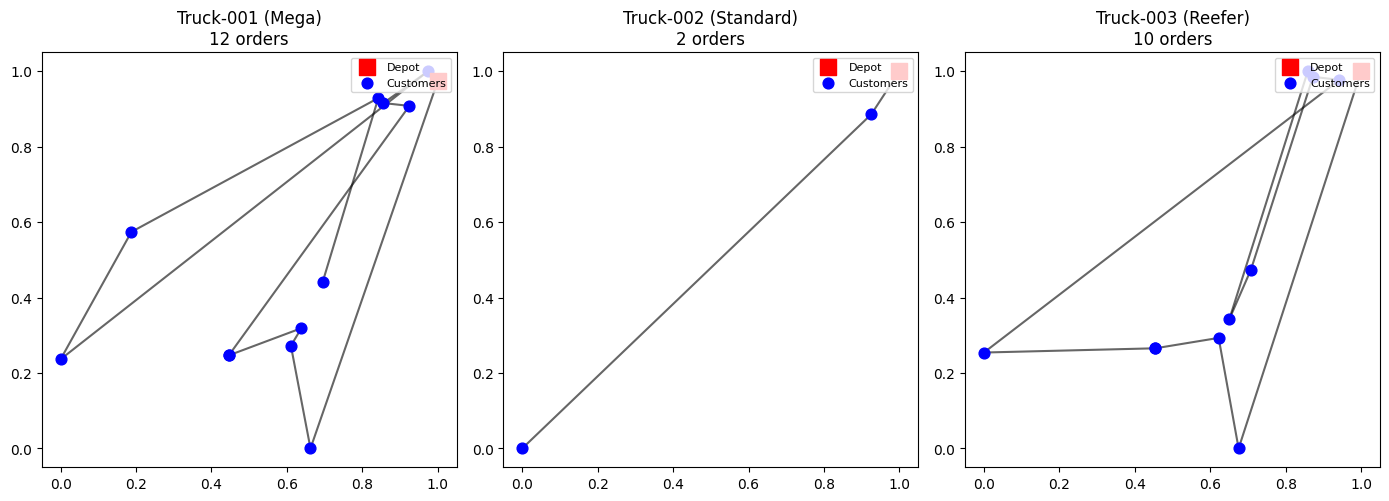

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for idx, truck in enumerate(fleet):
    print(f"{truck['vehicle_id']}: Allowed Goods = {truck['allowed_goods']}")
    result = prepare_data_for_routefinder(orders, truck)
    if result is None:
        axes[idx].text(0.5, 0.5, "No valid orders", ha="center", va="center")
        axes[idx].set_title(f"{truck['vehicle_id']}\n0 orders")
        continue
    td, filtered, all_coords = result
    td = env.reset(td) if hasattr(env, "reset") else td
    with torch.inference_mode():
        out = policy(td.clone().to(device), env, phase="test", decode_type="greedy", return_actions=True)
    actions = out["actions"]
    plot_route(td, actions, all_coords, filtered, truck["vehicle_id"], axes[idx])
plt.tight_layout()
plt.show()